In [71]:
from google.colab import files

uploaded = files.upload()

Saving googleplaystore.csv to googleplaystore (3).csv


In [72]:
import pandas as pd
df = pd.read_csv("googleplaystore.csv")


displaying data issues

In [73]:
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [74]:
df.duplicated().sum()

np.int64(483)

In [75]:
df.describe(include="object")


,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,596,1695,1579,10039,10040,8714,842,326,1459,2451


In [76]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [77]:
df_clean = df.copy()

drop duplicated

In [78]:
df_clean = df_clean.drop_duplicates()
df.duplicated().sum()


np.int64(483)

In [79]:
outliers = df_clean[(df_clean['Rating'] < lower_bound) | (df_clean['Rating'] > upper_bound)]

print(f"Q1 (25%): {Q1}")
print(f"Q3 (75%): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total Outliers Count: {len(outliers)}")
print("\nOutliers Sample:")
print(outliers[['App', 'Category', 'Rating']].head())

Q1 (25%): 4.1
Q3 (75%): 4.5
IQR: 0.40000000000000036
Lower Bound: 3.499999999999999
Upper Bound: 5.1000000000000005
Total Outliers Count: 724

Outliers Sample:
                                 App             Category  Rating
15   Learn To Draw Kawaii Characters       ART_AND_DESIGN     3.2
87     RST - Sale of cars on the PCT    AUTO_AND_VEHICLES     3.2
159                   Cloud of Books  BOOKS_AND_REFERENCE     3.3
176                 Free Book Reader  BOOKS_AND_REFERENCE     3.4
209                  Plugin:AOT v5.0             BUSINESS     3.1


fill missing values

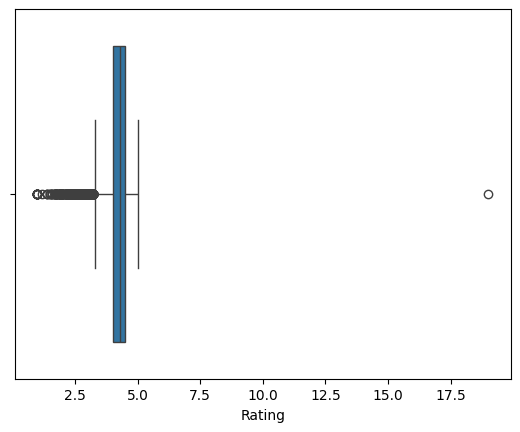

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=pd.to_numeric(df['Rating'], errors='coerce'))
plt.show()

In [81]:
#to know the outlier

df[pd.to_numeric(df['Rating'], errors='coerce') > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [82]:
# to remove outlier
df = df.drop(index=10472, errors='ignore')

In [83]:
df_clean['Rating'] = df_clean.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))